# Change Order Time Lifecycle Analysis

This notebook analyzes positive time-extension change orders by when they were created and approved within the project planned lifecycle.

Lifecycle percentages are calculated from the project-level planned envelope:

```text
ProjectPlannedStartDate = earliest contract StartDt across all contracts in the project
ProjectPlannedEndDate = latest contract ClosureDt across all contracts in the project
PercentOfProject = 100 * (ChangeOrderDate - ProjectPlannedStartDate) / ProjectPlannedDurationDays
```

Values are not clipped. A value above 100% means the change order occurred after the original planned project end date. That is analytically important for schedule risk because late time extensions may indicate risk that could not have been known early enough from the change-order record itself.

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)

PERCENT_BINS = [-np.inf, 0, 25, 50, 75, 100, 125, 150, 200, 300, 500, 1000, np.inf]
PERCENT_LABELS = ['<0%', '0-25%', '25-50%', '50-75%', '75-100%', '100-125%', '125-150%', '150-200%', '200-300%', '300-500%', '500-1000%', '>1000%']

def parse_dates(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df


def add_lifecycle_percentages(df):
    df = df.copy()
    valid_duration = pd.to_numeric(df['PROJECTPLANNEDDURATIONDAYS'], errors='coerce') > 0
    duration = pd.to_numeric(df['PROJECTPLANNEDDURATIONDAYS'], errors='coerce')
    for prefix, date_col in [('Created', 'CHANGEORDERCREATEDON'), ('Approved', 'CHANGEORDERAPPROVEDON')]:
        days_col = f'{prefix}DaysFromProjectStart'
        pct_col = f'{prefix}PercentOfProject'
        bin_col = f'{prefix}LifecycleBin'
        df[days_col] = (df[date_col] - df['PROJECTPLANNEDSTARTDATE']).dt.total_seconds() / 86400.0
        df[pct_col] = np.where(valid_duration & df[date_col].notna(), 100.0 * df[days_col] / duration, np.nan)
        df[bin_col] = pd.cut(df[pct_col], bins=PERCENT_BINS, labels=PERCENT_LABELS, right=True)
    df['HasValidProjectEnvelope'] = valid_duration & df['PROJECTPLANNEDSTARTDATE'].notna() & df['PROJECTPLANNEDENDDATE'].notna()
    return df


def coverage_table(df):
    rows = []
    for c in ['PROJECTPLANNEDSTARTDATE', 'PROJECTPLANNEDENDDATE', 'PROJECTPLANNEDDURATIONDAYS', 'CHANGEORDERCREATEDON', 'CHANGEORDERAPPROVEDON']:
        rows.append({'Field': c, 'NonNullRows': int(df[c].notna().sum()), 'Share': df[c].notna().mean()})
    rows.append({'Field': 'HasValidProjectEnvelope', 'NonNullRows': int(df['HasValidProjectEnvelope'].sum()), 'Share': df['HasValidProjectEnvelope'].mean()})
    return pd.DataFrame(rows)


def pct_summary(df, col):
    s = df[col].dropna()
    if s.empty:
        return pd.DataFrame()
    return s.describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]).to_frame(col).T


def plot_percent_histograms(df, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, col, label in [
        (axes[0], 'CreatedPercentOfProject', 'Created'),
        (axes[1], 'ApprovedPercentOfProject', 'Approved'),
    ]:
        s = df[col].dropna()
        ax.hist(s.clip(-100, 500), bins=80, color='#4c78a8', edgecolor='white')
        ax.axvline(100, color='firebrick', linestyle='--', linewidth=1.5, label='Original planned end')
        ax.axvline(0, color='black', linestyle=':', linewidth=1.2, label='Planned start')
        ax.set_title(f'{title}: {label} percent of planned project lifecycle\nvisual clipped to [-100%, 500%]')
        ax.set_xlabel('Percent of planned project lifecycle')
        ax.set_ylabel('Rows')
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_bin_bars(summary, value_col, title, ylabel):
    if summary.empty:
        return
    order = PERCENT_LABELS
    pivot = summary.pivot(index='LifecycleBin', columns='TimingBasis', values=value_col).reindex(order)
    ax = pivot.plot(kind='bar', figsize=(14, 5), color=['#4c78a8', '#f58518'], rot=45)
    ax.set_title(title)
    ax.set_xlabel('Lifecycle bin')
    ax.set_ylabel(ylabel)
    ax.legend(title='Timing basis')
    plt.tight_layout()
    plt.show()

DATA_PATH = Path('all_customer_change_order_time_lifecycle_2026-06-14-1124.csv')

## Load And Prepare Data

The extract is one row per positive time-extension change-order record. Created and approved lifecycle percentages are calculated independently. Rows without a valid project planned duration are retained for coverage reporting but excluded from percent/bin summaries.

In [2]:

df = pd.read_csv(DATA_PATH, low_memory=False)
df = parse_dates(df, [
    'PROJECTPLANNEDSTARTDATE', 'PROJECTPLANNEDENDDATE', 'ORIGINALCONTRACTSTARTDATE',
    'ORIGINALCONTRACTENDDATE', 'CHANGEORDERCREATEDON', 'CHANGEORDERAPPROVEDON',
    'CHANGEORDERBEGINDATE', 'CURRENTCOMPLETIONEND', 'NEWENDDATE'
])
df = add_lifecycle_percentages(df)
df['ADDEDDAYS'] = pd.to_numeric(df['ADDEDDAYS'], errors='coerce')
print(f'Rows: {len(df):,}')
print(f'Distinct change orders: {df["CHANGEORDERID"].nunique():,}')
print(f'Distinct projects: {df[["CUSTOMERNAME", "PROJECTID"]].drop_duplicates().shape[0]:,}')
display(df.head())


Rows: 1,667
Distinct change orders: 1,518
Distinct projects: 1,050


,CUSTOMERNAME,PROJECTID,PROJECTNAME,PROJECTPLANNEDSTARTDATE,PROJECTPLANNEDENDDATE,PROJECTPLANNEDDURATIONDAYS,PROJECTCONTRACTCOUNT,CONTRACTID,CONTRACTNAME,ORIGINALCONTRACTSTARTDATE,ORIGINALCONTRACTENDDATE,ORIGINALCONTRACTDAYS,LATESTCONTRACTSTARTDATE,LATESTCONTRACTENDDATE,NEWTOTALCONTRACTDAYS,CHANGEORDERID,CHANGEORDERNUMBER,CHANGEORDERCREATEDON,CHANGEORDERAPPROVEDON,ISAPPROVED,LATESTCONTRACTDAYSBEFORECHANGE,ADDEDDAYS,CHANGEORDERBEGINDATE,CURRENTCOMPLETIONEND,NEWENDDATE,TOTALDAYSADDEDONCONTRACT,TOTALDAYSEXTENDEDONCONTRACT,CreatedDaysFromProjectStart,CreatedPercentOfProject,CreatedLifecycleBin,ApprovedDaysFromProjectStart,ApprovedPercentOfProject,ApprovedLifecycleBin,HasValidProjectEnvelope
0,Adams,54,2013 Facilities Parking Lots Maintenance Project,2013-06-03 06:00:00,NaT,NaN,1,55,2013 Facilities Parking Lots Maintenance Project,2013-06-03 06:00:00,NaT,NaN,NaN,NaN,0.0,131,4,2013-09-11 15:54:44.690,2013-09-27 15:18:25.977,1,33.0,5.0,2013-06-30 06:00:00,NaT,2013-07-05 06:00:00,NaN,NaN,100.413017,NaN,NaN,116.387801,NaN,NaN,False
1,Adams,55,2013 Street Paving Program,2013-07-15 06:00:00,NaT,NaN,1,56,2013 Street Paving Program,2013-07-15 06:00:00,NaT,NaN,NaN,NaN,0.0,136,4,2013-10-23 14:02:36.697,2013-11-13 14:54:20.053,1,123.0,3.0,2013-11-10 07:00:00,NaT,2013-11-13 07:00:00,NaN,NaN,100.335147,NaN,NaN,121.371065,NaN,NaN,False
2,Adams,55,2013 Street Paving Program,2013-07-15 06:00:00,NaT,NaN,1,56,2013 Street Paving Program,2013-07-15 06:00:00,NaT,NaN,NaN,NaN,0.0,139,5,2013-11-08 15:07:04.730,2013-12-17 17:24:46.193,1,159.0,20.0,2013-11-10 07:00:00,NaT,2013-11-30 07:00:00,NaN,NaN,116.379916,NaN,NaN,155.475535,NaN,NaN,False
3,Adams,55,2013 Street Paving Program,2013-07-15 06:00:00,NaT,NaN,1,56,2013 Street Paving Program,2013-07-15 06:00:00,NaT,NaN,NaN,NaN,0.0,142,6,2013-11-20 16:41:37.537,2013-12-14 01:13:26.867,1,134.0,11.0,2013-11-13 07:00:00,NaT,2013-11-24 07:00:00,NaN,NaN,128.445573,NaN,NaN,151.801005,NaN,NaN,False
4,Adams,55,2013 Street Paving Program,2013-07-15 06:00:00,NaT,NaN,1,56,2013 Street Paving Program,2013-07-15 06:00:00,NaT,NaN,NaN,NaN,0.0,144,8,2013-11-21 15:41:06.807,2013-12-14 01:14:46.827,1,139.0,5.0,2013-11-13 07:00:00,NaT,2013-11-18 07:00:00,NaN,NaN,129.403551,NaN,NaN,151.801931,NaN,NaN,False


## Coverage And Missingness

This section shows whether lifecycle percentages can be computed. A valid project envelope requires a project planned start, planned end, and positive planned duration.

In [3]:

display(coverage_table(df).style.format({'Share': '{:.1%}'}))
customer_coverage = df.groupby('CUSTOMERNAME').agg(
    Rows=('CHANGEORDERID', 'size'),
    DistinctProjects=('PROJECTID', 'nunique'),
    DistinctChangeOrders=('CHANGEORDERID', 'nunique'),
    HasValidEnvelope=('HasValidProjectEnvelope', 'mean'),
    ApprovedShare=('ISAPPROVED', 'mean'),
    TotalAddedDays=('ADDEDDAYS', 'sum'),
).reset_index()
display(customer_coverage.style.format({'HasValidEnvelope': '{:.1%}', 'ApprovedShare': '{:.1%}', 'TotalAddedDays': '{:,.0f}'}))


,Field,NonNullRows,Share
0,PROJECTPLANNEDSTARTDATE,1667,100.0%
1,PROJECTPLANNEDENDDATE,1514,90.8%
2,PROJECTPLANNEDDURATIONDAYS,1514,90.8%
3,CHANGEORDERCREATEDON,1667,100.0%
4,CHANGEORDERAPPROVEDON,1595,95.7%
5,HasValidProjectEnvelope,1466,87.9%


,CUSTOMERNAME,Rows,DistinctProjects,DistinctChangeOrders,HasValidEnvelope,ApprovedShare,TotalAddedDays
0,Adams,82,35,82,72.0%,98.8%,"6,117"
1,Amtrak,12,5,12,100.0%,100.0%,"2,838"
2,CCD,92,56,92,100.0%,92.4%,"11,722"
3,CLV,167,71,167,87.4%,85.0%,"5,249"
4,Lincoln,396,323,396,62.6%,97.0%,"39,819"
5,UDOT,918,560,918,99.0%,97.1%,"18,941"


## Raw Lifecycle Percentage Distributions

These are raw percentages, not clipped. Values above 100% indicate activity after the original planned project end date.

Created percent summary


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
CreatedPercentOfProject,1466.0,747.794173,6602.086288,-907.245778,-18.060401,9.242777,26.588427,62.332436,105.017796,174.260918,319.386225,464.836172,15138.728891,119087.773116


Approved percent summary


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
ApprovedPercentOfProject,1404.0,794.067141,6689.319147,-907.244491,3.014816,27.45325,50.686823,85.808541,145.610689,246.868146,433.738435,596.932023,5414.845249,119182.211259


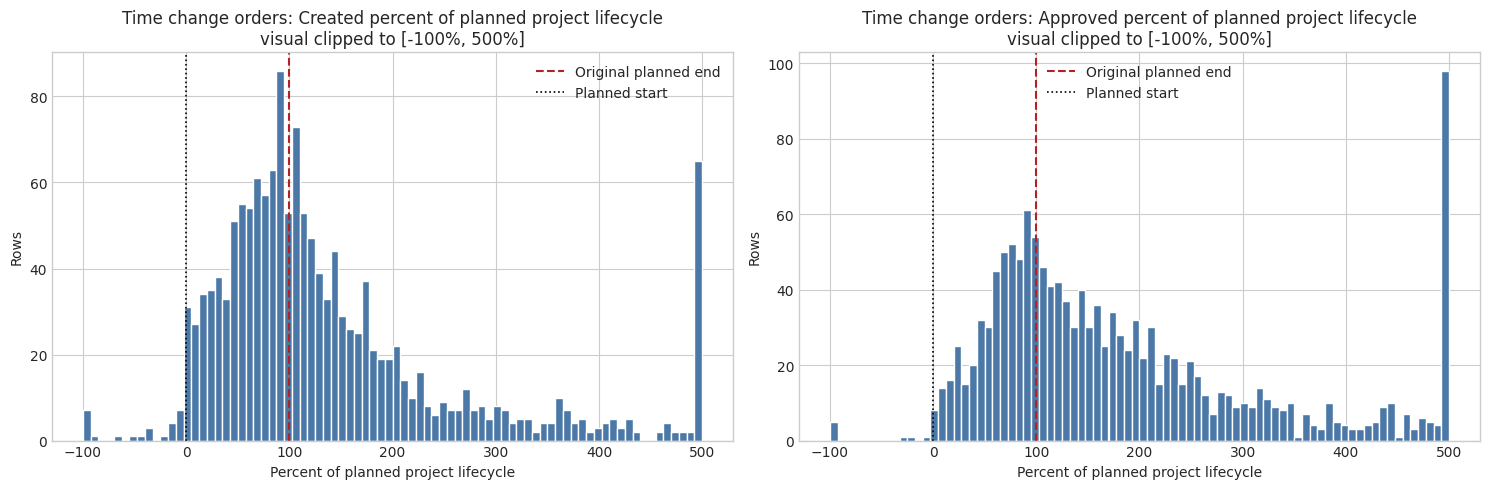

In [4]:

print('Created percent summary')
display(pct_summary(df, 'CreatedPercentOfProject'))
print('Approved percent summary')
display(pct_summary(df, 'ApprovedPercentOfProject'))
plot_percent_histograms(df, 'Time change orders')


## Binned Counts And Added-Day Sums

Bins are intentionally broad above 100% for the first pass. The raw percentages remain available for later bin refinement.

,LifecycleBin,ChangeOrderRows,DistinctChangeOrders,DistinctProjects,TotalAddedDays,MeanAddedDays,MedianAddedDays,TimingBasis
12,<0%,8,8,5,73.0,9.125000,3.5,ApprovedOn
13,0-25%,50,50,40,1804.0,36.080000,11.5,ApprovedOn
14,25-50%,80,80,70,3760.0,47.000000,11.0,ApprovedOn
15,50-75%,146,145,110,6400.0,43.835616,8.0,ApprovedOn
16,75-100%,177,175,142,7998.0,45.186441,17.0,ApprovedOn
17,100-125%,146,146,128,6140.0,42.054795,16.0,ApprovedOn
18,125-150%,117,116,105,5490.0,46.923077,11.0,ApprovedOn
19,150-200%,199,197,165,6796.0,34.150754,13.0,ApprovedOn
20,200-300%,222,221,180,8943.0,40.283784,12.0,ApprovedOn
21,300-500%,162,162,126,8210.0,50.679012,13.5,ApprovedOn


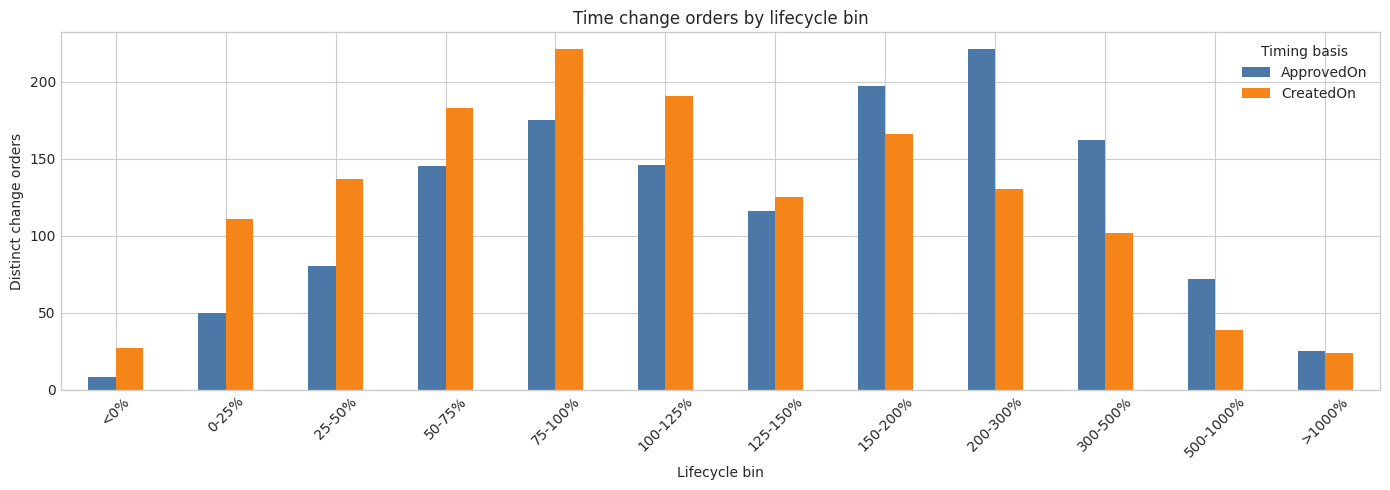

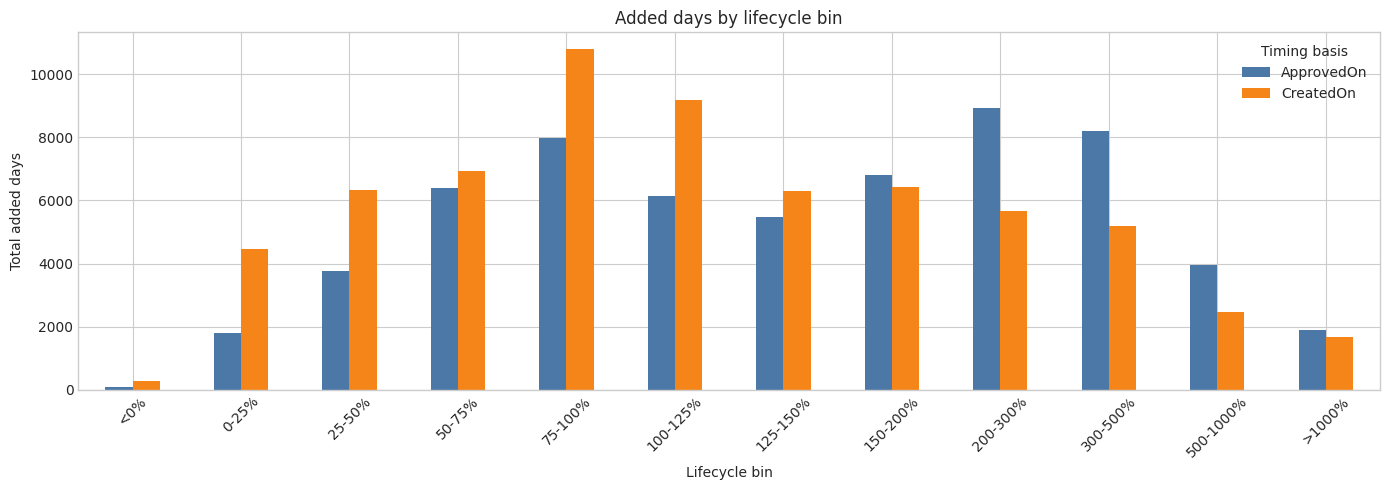

In [5]:

created = df[df['CreatedLifecycleBin'].notna()].groupby('CreatedLifecycleBin', observed=False).agg(
    ChangeOrderRows=('CHANGEORDERID', 'size'),
    DistinctChangeOrders=('CHANGEORDERID', 'nunique'),
    DistinctProjects=('PROJECTID', 'nunique'),
    TotalAddedDays=('ADDEDDAYS', 'sum'),
    MeanAddedDays=('ADDEDDAYS', 'mean'),
    MedianAddedDays=('ADDEDDAYS', 'median'),
).reset_index().rename(columns={'CreatedLifecycleBin': 'LifecycleBin'})
created['TimingBasis'] = 'CreatedOn'
approved = df[df['ApprovedLifecycleBin'].notna()].groupby('ApprovedLifecycleBin', observed=False).agg(
    ChangeOrderRows=('CHANGEORDERID', 'size'),
    DistinctChangeOrders=('CHANGEORDERID', 'nunique'),
    DistinctProjects=('PROJECTID', 'nunique'),
    TotalAddedDays=('ADDEDDAYS', 'sum'),
    MeanAddedDays=('ADDEDDAYS', 'mean'),
    MedianAddedDays=('ADDEDDAYS', 'median'),
).reset_index().rename(columns={'ApprovedLifecycleBin': 'LifecycleBin'})
approved['TimingBasis'] = 'ApprovedOn'
bin_summary = pd.concat([created, approved], ignore_index=True)
bin_summary['LifecycleBin'] = pd.Categorical(bin_summary['LifecycleBin'], categories=PERCENT_LABELS, ordered=True)
bin_summary = bin_summary.sort_values(['TimingBasis', 'LifecycleBin'])
display(bin_summary)
plot_bin_bars(bin_summary, 'DistinctChangeOrders', 'Time change orders by lifecycle bin', 'Distinct change orders')
plot_bin_bars(bin_summary, 'TotalAddedDays', 'Added days by lifecycle bin', 'Total added days')


## Late Change-Order Activity

This section focuses on change orders created or approved after 100% of the planned project lifecycle.

In [6]:

late_summary = pd.DataFrame([
    {
        'TimingBasis': 'CreatedOn',
        'RowsWithPercent': int(df['CreatedPercentOfProject'].notna().sum()),
        'RowsAfter100Pct': int((df['CreatedPercentOfProject'] > 100).sum()),
        'ShareAfter100Pct': (df['CreatedPercentOfProject'] > 100).sum() / max(df['CreatedPercentOfProject'].notna().sum(), 1),
        'AddedDaysAfter100Pct': df.loc[df['CreatedPercentOfProject'] > 100, 'ADDEDDAYS'].sum(),
    },
    {
        'TimingBasis': 'ApprovedOn',
        'RowsWithPercent': int(df['ApprovedPercentOfProject'].notna().sum()),
        'RowsAfter100Pct': int((df['ApprovedPercentOfProject'] > 100).sum()),
        'ShareAfter100Pct': (df['ApprovedPercentOfProject'] > 100).sum() / max(df['ApprovedPercentOfProject'].notna().sum(), 1),
        'AddedDaysAfter100Pct': df.loc[df['ApprovedPercentOfProject'] > 100, 'ADDEDDAYS'].sum(),
    }
])
display(late_summary.style.format({'ShareAfter100Pct': '{:.1%}', 'AddedDaysAfter100Pct': '{:,.0f}'}))
late_by_customer = df.groupby('CUSTOMERNAME').agg(
    Rows=('CHANGEORDERID', 'size'),
    CreatedAfter100=('CreatedPercentOfProject', lambda s: int((s > 100).sum())),
    ApprovedAfter100=('ApprovedPercentOfProject', lambda s: int((s > 100).sum())),
    TotalAddedDays=('ADDEDDAYS', 'sum'),
    AddedDaysCreatedAfter100=('ADDEDDAYS', lambda s: df.loc[s.index[df.loc[s.index, 'CreatedPercentOfProject'] > 100]].ADDEDDAYS.sum()),
    AddedDaysApprovedAfter100=('ADDEDDAYS', lambda s: df.loc[s.index[df.loc[s.index, 'ApprovedPercentOfProject'] > 100]].ADDEDDAYS.sum()),
).reset_index()
display(late_by_customer)


,TimingBasis,RowsWithPercent,RowsAfter100Pct,ShareAfter100Pct,AddedDaysAfter100Pct
0,CreatedOn,1466,782,53.3%,"36,935"
1,ApprovedOn,1404,943,67.2%,"41,444"


,CUSTOMERNAME,Rows,CreatedAfter100,ApprovedAfter100,TotalAddedDays,AddedDaysCreatedAfter100,AddedDaysApprovedAfter100
0,Adams,82,25,32,6117.0000,3891.0,4349.0
1,Amtrak,12,2,2,2838.0000,673.0,673.0
2,CCD,92,42,44,11722.0000,5490.0,5576.0
3,CLV,167,58,45,5249.0000,2222.0,1574.0
4,Lincoln,396,129,178,39819.0834,12582.0,15337.0
5,UDOT,918,526,642,18941.0000,12077.0,13935.0


## Exported Notebook Tables

In [7]:

bin_summary.to_csv('change_order_time_lifecycle_bin_summary_2026-06-14.csv', index=False)
late_summary.to_csv('change_order_time_lifecycle_late_summary_2026-06-14.csv', index=False)
df.to_csv('change_order_time_lifecycle_with_percentages_2026-06-14.csv', index=False)
print('Saved time lifecycle summary CSVs.')


Saved time lifecycle summary CSVs.
